In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/weatherHistory.csv")

df

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
55362,2012-02-03 18:00:00.000 +0100,Foggy,snow,-10.000000,-16.150000,0.84,12.8800,10.0,2.5760,0.0,1028.10,Foggy starting in the morning continuing until...
55363,2012-02-03 19:00:00.000 +0100,Foggy,snow,-10.033333,-15.861111,0.85,11.7530,18.0,2.3828,0.0,1028.09,Foggy starting in the morning continuing until...
55364,2012-02-03 20:00:00.000 +0100,Foggy,snow,-10.000000,-16.150000,0.84,12.8800,20.0,1.2880,0.0,1028.10,Foggy starting in the morning continuing until...
55365,2012-02-03 21:00:00.000 +0100,Foggy,snow,-10.000000,-15.666667,0.84,11.2700,20.0,1.2880,0.0,1028.20,Foggy starting in the morning continuing until...


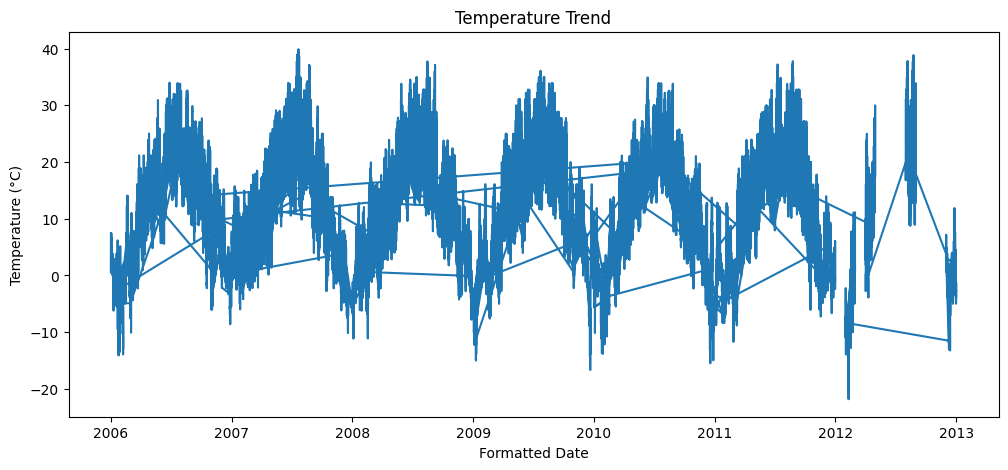

In [ ]:
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)

plt.figure(figsize=(12,5))
plt.plot(df['Formatted Date'], df['Temperature (C)'])
plt.title("Temperature Trend")
plt.xlabel("Formatted Date")
plt.ylabel("Temperature (°C)")
plt.show()

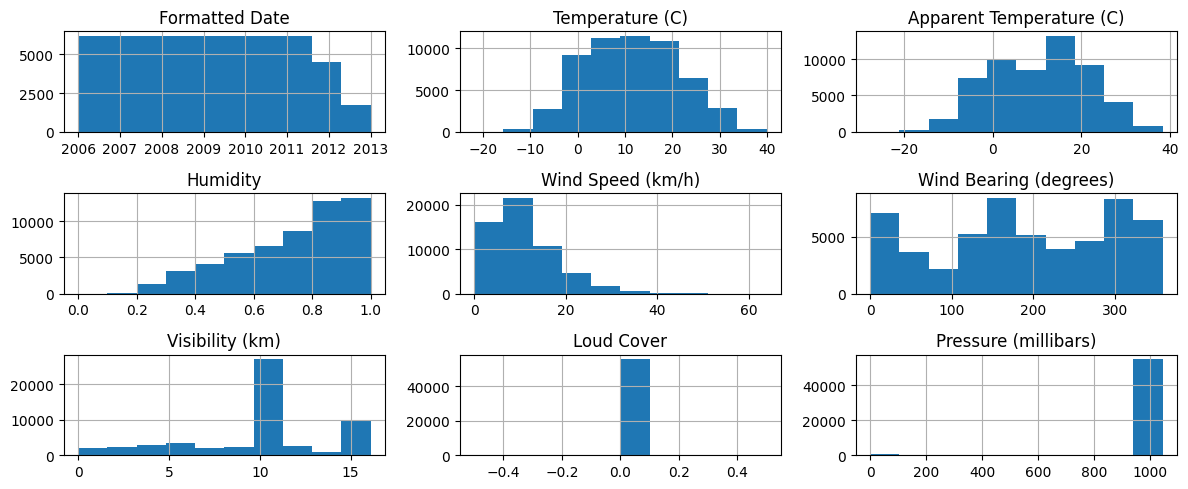

In [ ]:
df.hist(figsize=(12,5))
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

df['Days'] = np.arange(len(df))

X = df[['Days']]
y = df['Temperature (C)']

model = LinearRegression()
model.fit(X, y)

LinearRegression()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


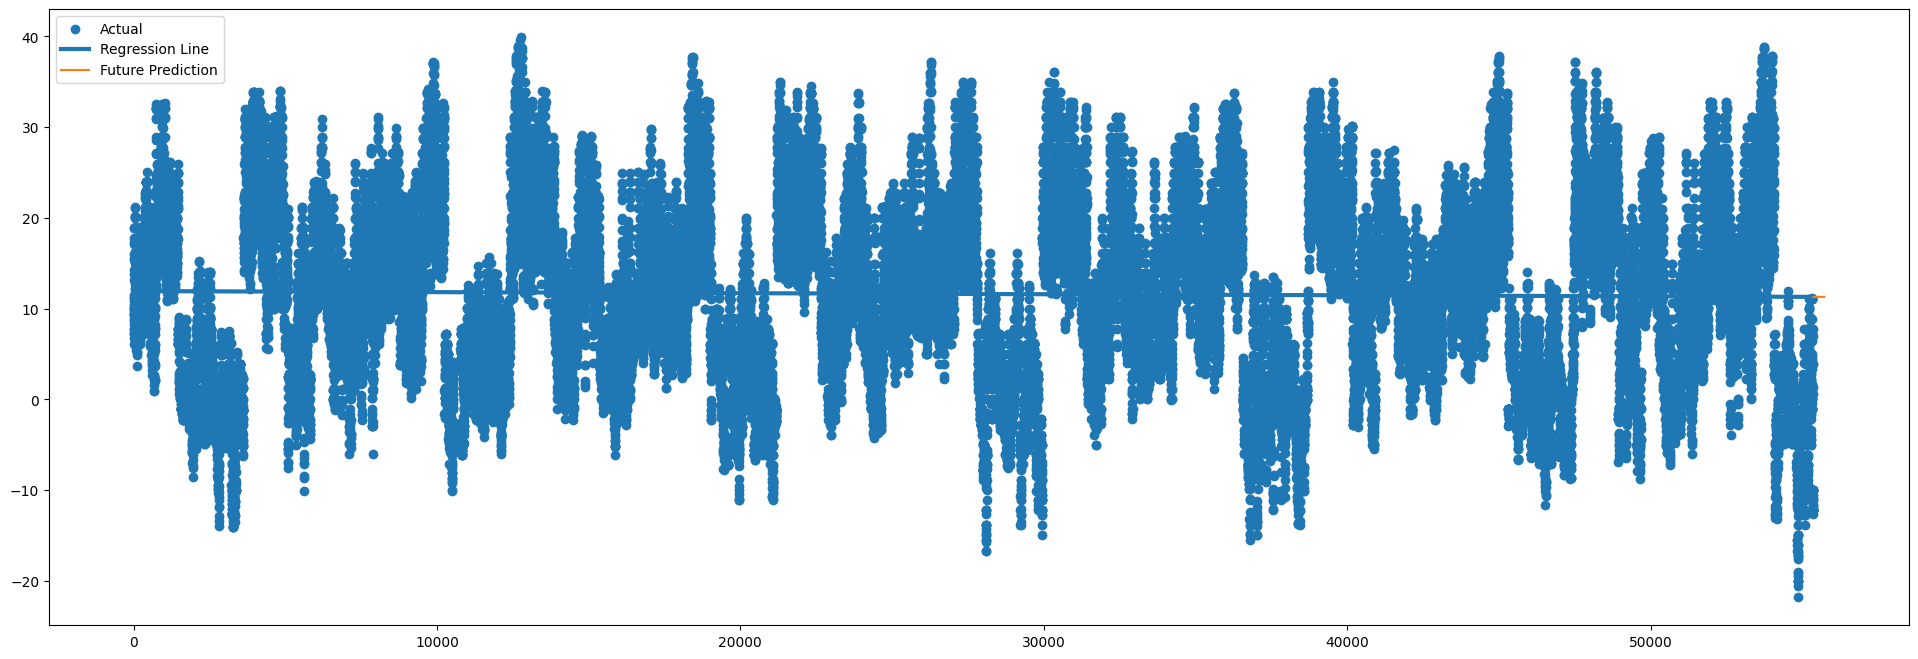

In [ ]:
plt.figure(figsize=(24,8))

plt.scatter(df['Days'], y, label='Actual')

plt.plot(df['Days'],model.predict(X),linewidth=3,label='Regression Line')
last_day = df['Days'].max()
future_days = np.arange(last_day + 1, last_day + 366)
future_temp = model.predict(future_days.reshape(-1, 1))

plt.plot(future_days,
         future_temp,
         label='Future Prediction')

plt.legend()
plt.show()

In [ ]:
print("Average Temp :", df['Temperature (C)'].mean())

print("Maximum Temp :", df['Temperature (C)'].max())

print("Minimum Temp :", df['Temperature (C)'].min())

print("Predicted Temp after 30 days :",
      future_temp[-1])

Average Temp : 11.610607200839649
Maximum Temp : 39.90555555555555
Minimum Temp : -21.822222222222223
Predicted Temp after 30 days : 11.287328819212657
